# Detección de Anomalías con Autoencoders en el Molino Coloidal: Química Latinoamericana
### Comparación de técnicas de regularización y exportación del modelo

**Datos:** `Dataset_Molino_QLA_Realista.zip` (1 año, 1 lectura por minuto) y `Bitacora_Mantenimiento_QLA.csv`

# 1. Introducción

## 1.1 Problemática

El sistema de monitoreo del molino ya cuenta con:

* **LightGBM** para identificar las siete fallas conocidas.
* **Reglas fijas** para fallas de instrumento (lazo sobre 21 mA, Pt100 sin alimentación).
* Un **modelo predictivo** para anticipar fallas a 24 horas, 5 días y 15 días.

Pero todos estos modelos dependen de **ejemplos de falla**. En la identificación, LightGBM casi no reconoció el radar sucio, el ensuciamiento del intercambiador ni el desgaste de rodamientos, porque en el entrenamiento hubo muy pocos minutos de esas fallas. Además, en la planta real habrá problemas que **ninguna etiqueta cubre**: la válvula de 3 vías trabada, la bomba cavitando, una limpieza de línea incompleta.

## 1.2 Solución: autoencoder entrenado con la planta sana

Un **autoencoder** es una red neuronal que aprende a copiar su entrada en su salida pasando por un cuello de botella:

```
  sensores del molino ──► [Codificador] ──► 8 neuronas ──► [Decodificador] ──► sensores reconstruidos
```

Se entrena **solo con operación sana**. Así aprende las relaciones físicas normales entre los sensores: la corriente del motor según el tipo de asfalto, la presión del filtro según el caudal, la temperatura de la emulsión según la del betún y la solución.

* Lectura sana → se reconstruye bien → **error bajo**.
* Lectura anómala, aunque sea de una falla que nunca se vio → rompe esas relaciones → **error alto** → **alarma**.

Para el autoencoder **todas las fallas son desconocidas**: ninguna aparece en su entrenamiento. Por eso medir cuánto detecta de cada una es directamente una prueba de su capacidad para detectar lo nuevo.

## 1.3 Objetivos

1. Entrenar un autoencoder con la operación sana del molino en marcha.
2. Comparar **seis variantes de regularización**: sin regularización, L2, sparse, Dropout, denoising y combinada.
3. Compararlo con **PCA** e **Isolation Forest**.
4. Medir cuánto **complementa a LightGBM**, en especial en las fallas raras.
5. Usar su error como **índice de salud** del molino para el mantenimiento predictivo.
6. Exportar el mejor modelo.

# 2. Carga y preprocesamiento de datos

## 2.1 Librerías

In [1]:
import os
import time
import zipfile
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GaussianNoise
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l1, l2

import lightgbm as lgb
from lightgbm import LGBMClassifier
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
                             roc_auc_score, average_precision_score, roc_curve, precision_recall_curve)

import warnings
warnings.filterwarnings("ignore")
SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
pd.set_option("display.width", 200)
print("TensorFlow:", tf.__version__, "| scikit-learn:", sklearn.__version__, "| LightGBM:", lgb.__version__)

I0000 00:00:1790889850.790568    6980 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790889850.836783    6980 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1790889852.121517    6980 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0 | scikit-learn: 1.8.0 | LightGBM: 4.7.0


## 2.2 Carga del dataset y la bitácora

In [2]:
RUTA = "Dataset_Molino_QLA_Realista.zip"
RUTA_BIT = "Bitacora_Mantenimiento_QLA.csv"
faltan = [r for r in (RUTA, RUTA_BIT) if not os.path.exists(r)]
if faltan:
    try:
        from google.colab import files
        print("Sube los archivos:", ", ".join(faltan))
        files.upload()
    except ImportError:
        raise FileNotFoundError(f"No se encontraron: {faltan}")

TARGET = "LABEL_Estado_Planta"
df_completo = pd.read_csv(RUTA, parse_dates=["timestamp"])
bit = pd.read_csv(RUTA_BIT, parse_dates=["timestamp"])
print(f"Dataset: {len(df_completo):,} minutos | Bitácora: {len(bit)} intervenciones".replace(",", "."))
df_completo[TARGET].value_counts().to_frame("minutos")

Dataset: 525.600 minutos | Bitácora: 60 intervenciones


,minutos
LABEL_Estado_Planta,
Normal,502013
Advertencia_Radar_Sucio_Betun,10893
Falla_Electrica_PT100_Betun,7434
Sobrecarga_Motor_Por_Asfalto_Frio,3419
Cortocircuito_Transmisor_Caudal_Sol,1328
Filtro_Obstruido,327
Ensuciamiento_Intercambiador,133
Desgaste_Rodamientos_Molino,53


## 2.3 Alcance: molino en marcha

Igual que en los modelos anteriores, el autoencoder se aplica **solo con el molino en marcha** (producción o limpieza de línea). Con el motor detenido, corriente y vibración están en cero, y eso no es una anomalía.

In [3]:
df = df_completo[df_completo["ESTADO_operacion"].isin(["Produccion", "Limpieza"])].reset_index(drop=True)
CORTO = {"Normal": "Normal", "Sobrecarga_Motor_Por_Asfalto_Frio": "Sobrecarga", "Filtro_Obstruido": "Filtro",
         "Advertencia_Radar_Sucio_Betun": "Radar sucio", "Cortocircuito_Transmisor_Caudal_Sol": "Cortocircuito",
         "Falla_Electrica_PT100_Betun": "Pt100", "Ensuciamiento_Intercambiador": "Intercambiador",
         "Desgaste_Rodamientos_Molino": "Rodamientos"}
print(f"Minutos con el molino en marcha: {len(df):,}".replace(",", "."))
df[TARGET].map(CORTO).value_counts().to_frame("minutos")

Minutos con el molino en marcha: 42.730


,minutos
LABEL_Estado_Planta,
Normal,37676
Sobrecarga,3419
Radar sucio,579
Filtro,327
Cortocircuito,280
Pt100,263
Intercambiador,133
Rodamientos,53


## 2.4 Selección de variables

Mismos criterios que en los modelos de identificación:

* Se eliminan las variables de **nivel de estanque** (describen cuánto producto hay, no la salud del equipo) y las columnas constantes.
* `POS_valvula_3vias` y `VAL_aire_linea` se reemplazan por una variable de contexto.

Se agregan dos **variables de contexto**: `es_plastomerico` y `en_limpieza`. Son indispensables para el autoencoder: sin ellas, un día plastomérico (betún a 190 °C, intercambiador a 2,5 bar) le parecería una anomalía, porque se aleja del convencional.

In [4]:
df["es_plastomerico"] = (df["TIPO_asfalto"] == "Plastomerico").astype(int)
df["en_limpieza"] = (df["ESTADO_operacion"] == "Limpieza").astype(int)
excluir = {"timestamp", TARGET, "ESTADO_operacion", "TIPO_asfalto", "POS_valvula_3vias", "VAL_aire_linea"}
candidatas = [c for c in df.columns if c not in excluir]
constantes = [c for c in candidatas if df[c].nunique() == 1]
NIVEL = [c for c in candidatas if any(k in c for k in ["POR_niv", "VOL_niv", "DIS_niv", "AMP_niv"])]
FEATURES = [c for c in candidatas if c not in constantes + NIVEL]
CONTEXTO = ["es_plastomerico", "en_limpieza"]
print(f"Variables de entrada ({len(FEATURES)}):", FEATURES)

Variables de entrada (31): ['TEM_son_betum_in', 'RES_son_betum_in', 'VOLT_son_betum_in', 'AMP_son_betum_in', 'AMP_cau_betum_in', 'FRE_cau_betum_in', 'AMP_eco_betum_dep', 'EST_niv_betum_dep', 'TEM_son_solucion_in', 'RES_son_solucion_in', 'AMP_son_solucion_in', 'AMP_cau_solucion_in', 'FRE_cau_solucion_in', 'AMP_eco_solucion_dep', 'TEM_son_emulsion_out', 'RES_son_emulsion_out', 'AMP_cau_emulsion_out', 'FRE_cau_emulsion_out', 'AMP_eco_emulsion_dep', 'RPM_motor_molino', 'FRE_vfd_motor_molino', 'AMP_vfd_motor_molino', 'TOR_vfd_motor_molino', 'VIB_vel_motor_molino', 'AMP_vib_motor_molino', 'CAU_bomba_lpm', 'PRE_dif_filtro_bar', 'TEM_emulsion_molino_out', 'PRE_intercambiador_bar', 'es_plastomerico', 'en_limpieza']


## 2.5 ¿Qué es "operación sana"?

En este dataset las fallas se desarrollan por **degradación progresiva**. Los días previos a una falla están etiquetados como "Normal", pero los sensores ya se están desviando: el filtro se va ensuciando, la vibración va subiendo.

Si el autoencoder se entrena con esos días, aprende que la degradación es normal y pierde sensibilidad justo donde más importa. Por eso se define **operación sana** como los minutos normales que **no están dentro de los 7 días previos al inicio de ninguna falla**.

In [5]:
etq = df_completo[TARGET]
inicio_fallas = np.sort(df_completo.loc[(etq != "Normal") & (etq.shift() != etq), "timestamp"].values)
idx = np.searchsorted(inicio_fallas, df["timestamp"].values, side="right")
ok = idx < len(inicio_fallas)
horas_a_falla = np.full(len(df), np.inf)
horas_a_falla[ok] = (inicio_fallas[idx[ok]] - df["timestamp"].values[ok]) / np.timedelta64(1, "h")
df["horas_a_falla"] = horas_a_falla
df["sano"] = (df[TARGET] == "Normal") & (df["horas_a_falla"] > 7 * 24)

print(f"Minutos normales: {(df[TARGET] == 'Normal').sum():,}".replace(",", "."))
print(f"Minutos sanos (normal y a más de 7 días de una falla): {df['sano'].sum():,}".replace(",", "."))

Minutos normales: 37.676
Minutos sanos (normal y a más de 7 días de una falla): 15.413


## 2.6 División cronológica

| Conjunto | Periodo | Contenido | Uso |
|---|---|---|---|
| **Entrenamiento** | Enero a junio | Solo minutos sanos | Ajustar los pesos |
| **Validación sana** | Julio y agosto | Solo minutos sanos | EarlyStopping y **umbral** |
| **Validación completa** | Julio y agosto | Todos los minutos | Elegir la mejor variante |
| **Prueba** | Septiembre a diciembre | Todos los minutos | Evaluación final |

El entrenamiento **no usa ninguna etiqueta de falla**.

In [6]:
FIN_TR, FIN_VA = pd.Timestamp("2026-07-01"), pd.Timestamp("2026-09-01")
tr = (df["timestamp"] < FIN_TR).values
va = ((df["timestamp"] >= FIN_TR) & (df["timestamp"] < FIN_VA)).values
te = (df["timestamp"] >= FIN_VA).values
sano = df["sano"].values

scaler = StandardScaler().fit(df.loc[tr & sano, FEATURES])
X = scaler.transform(df[FEATURES]).astype("float32")
y = (df[TARGET] != "Normal").astype(int).values

X_train, X_val_sano = X[tr & sano], X[va & sano]
X_val, y_val = X[va], y[va]
X_test, y_test = X[te], y[te]
etq_test = df.loc[te, TARGET].values
print("Entrenamiento (sano):", X_train.shape, "| Validación sana:", X_val_sano.shape)
print("Validación completa:", X_val.shape, "| Prueba:", X_test.shape)
pd.DataFrame({"validación": df.loc[va, TARGET].map(CORTO).value_counts(),
              "prueba": df.loc[te, TARGET].map(CORTO).value_counts()}).fillna(0).astype(int)

Entrenamiento (sano): (8162, 31) | Validación sana: (1405, 31)
Validación completa: (7210, 31) | Prueba: (14274, 31)


,validación,prueba
LABEL_Estado_Planta,,
Cortocircuito,93,87
Filtro,38,132
Intercambiador,46,76
Normal,6554,12657
Pt100,90,26
Radar sucio,86,211
Rodamientos,22,31
Sobrecarga,281,1054


# 3. Definición de los autoencoders

## 3.1 Arquitectura y variantes de regularización

Arquitectura simétrica: entrada → 16 → **8 (cuello)** → 16 → salida, con ReLU en las capas ocultas y salida lineal.

En un autoencoder la regularización cumple un rol especial: una red demasiado flexible aprende a **copiar cualquier cosa**, incluidas las anomalías, y deja de detectarlas.

| Variante | Técnica | Qué hace |
|---|---|---|
| `base` | Solo EarlyStopping | Referencia |
| `l2` | L2 sobre los pesos (`λ = 1e-4`) | Pesos pequeños, reconstrucción suave |
| `sparse` | L1 sobre las activaciones del cuello (`λ = 1e-4`) | Pocas neuronas activas, representación compacta |
| `dropout` | Dropout 20 % | Impide depender de una sola neurona |
| `denoising` | Ruido gaussiano en la entrada (σ = 0,2) | Aprende a reconstruir la lectura limpia desde una ruidosa |
| `combinado` | L2 + ruido + Dropout | Todas las anteriores salvo sparse |

In [7]:
TIPOS_AE = ["base", "l2", "sparse", "dropout", "denoising", "combinado"]

def crear_autoencoder(tipo, n, cuello=8):
    rp = l2(1e-4) if tipo in ("l2", "combinado") else None
    ra = l1(1e-4) if tipo == "sparse" else None
    entrada = Input(shape=(n,))
    x = GaussianNoise(0.2)(entrada) if tipo in ("denoising", "combinado") else entrada
    x = Dense(16, activation="relu", kernel_regularizer=rp)(x)
    if tipo in ("dropout", "combinado"): x = Dropout(0.2)(x)
    z = Dense(cuello, activation="relu", kernel_regularizer=rp, activity_regularizer=ra, name="cuello")(x)
    x = Dense(16, activation="relu", kernel_regularizer=rp)(z)
    if tipo in ("dropout", "combinado"): x = Dropout(0.2)(x)
    salida = Dense(n, activation="linear", kernel_regularizer=rp)(x)
    m = Model(entrada, salida, name=f"AE_{tipo}")
    m.compile(optimizer=keras.optimizers.Adam(1e-3), loss="mse")
    return m

crear_autoencoder("combinado", len(FEATURES)).summary()

Model: "AE_combinado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise (GaussianNoise)  │ (None, 31)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cuello (Dense)                  │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 31)             │           527 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,319 (5.15 KB)

 Trainable params: 1,319 (5.15 KB)

 Non-trainable params: 0 (0.00 B)

## 3.2 Error, umbral y métricas

* **Puntaje de anomalía:** error cuadrático medio de reconstrucción por minuto.
* **Umbral:** percentil 99 del error en la **validación sana**. Se calcula sin mirar ninguna falla y equivale a aceptar ~1 % de falsas alarmas en operación sana.
* **Métricas:** ROC-AUC y PR-AUC (sin umbral) para comparar variantes; precision, recall, F1 y tasa de falsas alarmas (FAR) con el umbral.

Un detalle importante de este dataset: la FAR se mide sobre **todos** los minutos normales de prueba, incluidos los días previos a una falla, que ya muestran degradación. Parte de esas "falsas alarmas" son en realidad avisos tempranos (sección 6.2).

In [8]:
PERCENTIL = 99

def error_rec(modelo, X):
    return np.mean((X - modelo.predict(X, verbose=0, batch_size=4096)) ** 2, axis=1)

def metricas(puntaje, y, umbral):
    pred = (puntaje > umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    return {"ROC_AUC": roc_auc_score(y, puntaje), "PR_AUC": average_precision_score(y, puntaje),
            "precision": precision_score(y, pred, zero_division=0), "recall": recall_score(y, pred, zero_division=0),
            "f1": f1_score(y, pred, zero_division=0), "FAR": fp / (fp + tn), "falsas_alarmas": int(fp),
            "fallas_no_detectadas": int(fn)}

## 3.3 Entrenamiento

In [9]:
autoencoders, historiales, umbrales, filas = {}, {}, {}, []
for tipo in TIPOS_AE:
    tf.keras.utils.set_random_seed(SEED)
    ae = crear_autoencoder(tipo, len(FEATURES))
    t0 = time.time()
    h = ae.fit(X_train, X_train, validation_data=(X_val_sano, X_val_sano), epochs=150, batch_size=128, verbose=0,
               callbacks=[EarlyStopping(monitor="val_loss", patience=12, restore_best_weights=True),
                          ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-5)])
    autoencoders[tipo], historiales[tipo] = ae, h.history
    e_tr, e_vs = error_rec(ae, X_train).mean(), error_rec(ae, X_val_sano)
    umbrales[tipo] = float(np.percentile(e_vs, PERCENTIL))
    m_val = metricas(error_rec(ae, X_val), y_val, umbrales[tipo])
    filas.append({"variante": f"AE_{tipo}", "epocas": len(h.history["loss"]), "mse_train": e_tr, "mse_val_sano": e_vs.mean(),
                  "brecha_val/train": e_vs.mean() / e_tr, "umbral": umbrales[tipo],
                  "PR_AUC_val": m_val["PR_AUC"], "ROC_AUC_val": m_val["ROC_AUC"], "seg": round(time.time() - t0, 1)})
tabla_ent = pd.DataFrame(filas).set_index("variante")
tabla_ent.round(4)

,epocas,mse_train,mse_val_sano,brecha_val/train,umbral,PR_AUC_val,ROC_AUC_val,seg
variante,,,,,,,,
AE_base,97,0.0638,0.0903,1.4153,0.3525,0.3766,0.7907,19.6
AE_l2,150,0.0321,0.0459,1.4300,0.2286,0.4100,0.7829,32.2
AE_sparse,72,0.0697,0.0951,1.3634,0.3839,0.3784,0.7894,15.9
AE_dropout,97,0.2198,0.2925,1.3305,0.7139,0.3887,0.7622,22.3
AE_denoising,31,0.1334,0.1882,1.4099,0.5022,0.4594,0.7658,7.8
AE_combinado,104,0.2187,0.3339,1.5263,0.7684,0.4435,0.7538,29.8


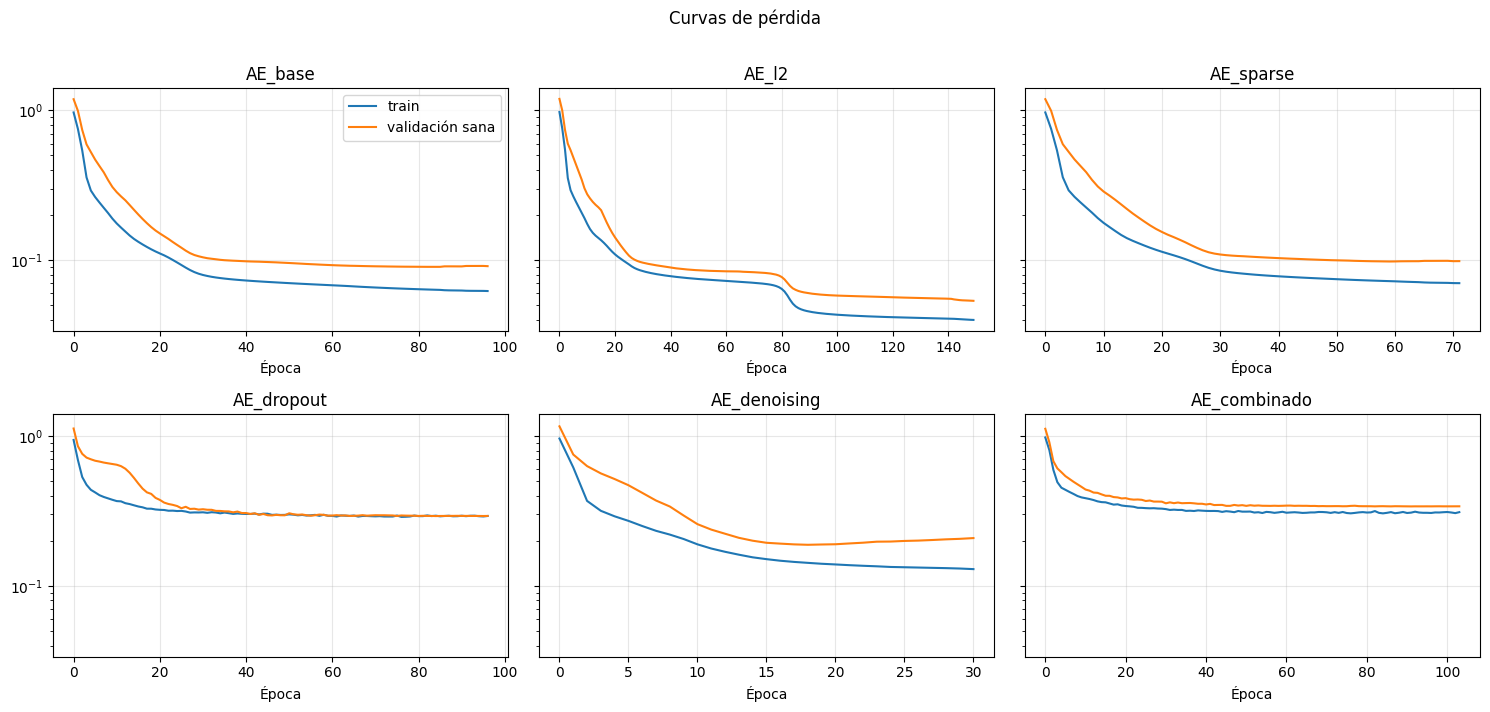

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7), sharey=True)
for ax, (tipo, h) in zip(axes.ravel(), historiales.items()):
    ax.plot(h["loss"], label="train"); ax.plot(h["val_loss"], label="validación sana")
    ax.set_title(f"AE_{tipo}"); ax.set_yscale("log"); ax.grid(alpha=0.3); ax.set_xlabel("Época")
axes[0, 0].legend(); plt.suptitle("Curvas de pérdida", y=1.01); plt.tight_layout(); plt.show()

En las variantes con ruido o Dropout la pérdida de entrenamiento queda por encima de la de validación: esas técnicas solo actúan al entrenar, lo que hace más difícil la tarea de entrenamiento.

# 4. Comparación de las técnicas de regularización

## 4.1 Distribución del error en prueba

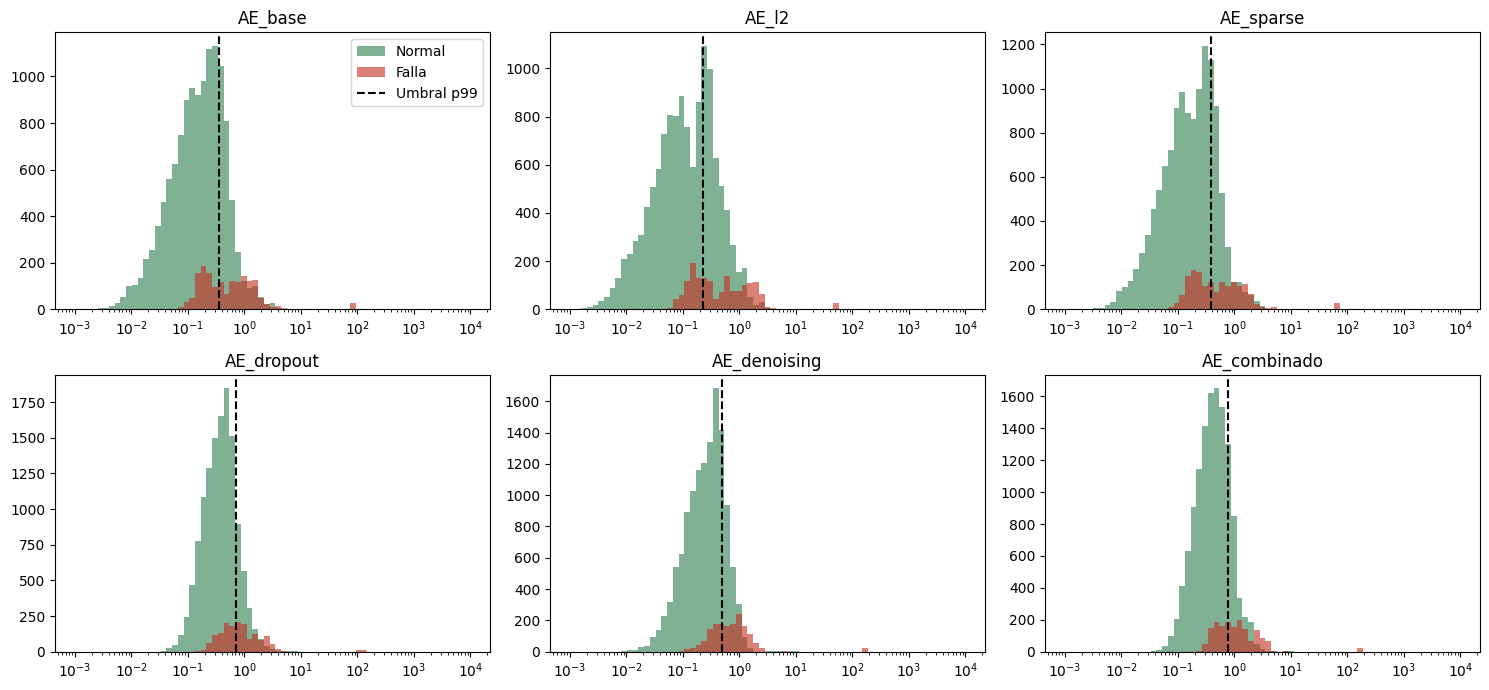

In [11]:
punt_test = {t: error_rec(m, X_test) for t, m in autoencoders.items()}
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
bins = np.logspace(-3, 4, 70)
for ax, (tipo, e) in zip(axes.ravel(), punt_test.items()):
    ax.hist(e[y_test == 0], bins=bins, alpha=0.6, color="#2E7D4F", label="Normal")
    ax.hist(e[y_test == 1], bins=bins, alpha=0.6, color="#C62D1F", label="Falla")
    ax.axvline(umbrales[tipo], color="black", ls="--", label="Umbral p99")
    ax.set_xscale("log"); ax.set_title(f"AE_{tipo}")
axes[0, 0].legend(); plt.tight_layout(); plt.show()

## 4.2 Métricas en prueba

In [12]:
res_test = pd.DataFrame({f"AE_{t}": metricas(punt_test[t], y_test, umbrales[t]) for t in TIPOS_AE}).T
res_test.insert(0, "PR_AUC_val", tabla_ent["PR_AUC_val"])
res_test.round(4)

,PR_AUC_val,ROC_AUC,PR_AUC,precision,recall,f1,FAR,falsas_alarmas,fallas_no_detectadas
AE_base,0.3766,0.7770,0.3661,0.2416,0.5696,0.3393,0.2284,2891.0,696.0
AE_l2,0.4100,0.7847,0.4075,0.2034,0.6407,0.3088,0.3205,4057.0,581.0
AE_sparse,0.3784,0.7603,0.3503,0.2358,0.5263,0.3257,0.2179,2758.0,766.0
AE_dropout,0.3887,0.7848,0.4032,0.3143,0.5510,0.4003,0.1536,1944.0,726.0
AE_denoising,0.4594,0.8185,0.4769,0.3010,0.6376,0.4090,0.1891,2394.0,586.0
AE_combinado,0.4435,0.8120,0.4471,0.2939,0.6104,0.3968,0.1873,2371.0,630.0


## 4.3 Detección por tipo de falla

Como ninguna falla se usó en el entrenamiento, esta tabla mide directamente la capacidad de detectar **fallas desconocidas**. La fila Normal es la tasa de falsas alarmas.

In [13]:
det_falla = pd.DataFrame({f"AE_{t}": pd.Series(punt_test[t] > umbrales[t]).groupby(pd.Series(etq_test).map(CORTO).values).mean()
                          for t in TIPOS_AE}).round(3)
det_falla.index.name = "fracción de minutos marcados como anomalía"
det_falla

,AE_base,AE_l2,AE_sparse,AE_dropout,AE_denoising,AE_combinado
fracción de minutos marcados como anomalía,,,,,,
Cortocircuito,1.000,1.000,1.000,0.655,0.724,0.425
Filtro,0.470,0.538,0.371,0.106,0.129,0.242
Intercambiador,0.711,0.711,0.711,0.737,0.737,0.763
Normal,0.228,0.321,0.218,0.154,0.189,0.187
Pt100,1.000,1.000,1.000,1.000,1.000,1.000
Radar sucio,0.943,1.000,0.787,0.654,0.995,0.905
Rodamientos,1.000,1.000,1.000,1.000,1.000,1.000
Sobrecarga,0.438,0.528,0.416,0.540,0.596,0.581


## 4.4 Selección de la mejor variante

Se elige la variante con mayor **PR-AUC en validación**.

In [14]:
MEJOR = tabla_ent["PR_AUC_val"].idxmax().replace("AE_", "")
mejor_ae, UMBRAL = autoencoders[MEJOR], umbrales[MEJOR]
err_test = punt_test[MEJOR]
print(f"Mejor variante: AE_{MEJOR} | umbral = {UMBRAL:.4f}")

Mejor variante: AE_denoising | umbral = 0.5022


# 5. Comparación con otros métodos

## 5.1 PCA e Isolation Forest

Ambos se entrenan con los mismos minutos sanos y usan el mismo criterio de umbral.

In [15]:
pca = PCA(n_components=8, random_state=SEED).fit(X_train)
p_pca = lambda Z: np.mean((Z - pca.inverse_transform(pca.transform(Z))) ** 2, axis=1)
iso = IsolationForest(n_estimators=300, random_state=SEED, n_jobs=-1).fit(X_train)
p_iso = lambda Z: -iso.score_samples(Z)

comp = {}
for nombre, fn in [(f"Autoencoder ({MEJOR})", lambda Z: error_rec(mejor_ae, Z)), ("PCA (8 comp.)", p_pca), ("Isolation Forest", p_iso)]:
    comp[nombre] = metricas(fn(X_test), y_test, np.percentile(fn(X_val_sano), PERCENTIL))
pd.DataFrame(comp).T.round(4)

,ROC_AUC,PR_AUC,precision,recall,f1,FAR,falsas_alarmas,fallas_no_detectadas
Autoencoder (denoising),0.8185,0.4769,0.3010,0.6376,0.4090,0.1891,2394.0,586.0
PCA (8 comp.),0.6750,0.2509,0.2208,0.1874,0.2027,0.0845,1069.0,1314.0
Isolation Forest,0.7818,0.2389,0.1040,0.0390,0.0567,0.0429,543.0,1554.0


## 5.2 ¿Cuánto complementa a LightGBM?

Se entrena un detector **LightGBM supervisado** (Normal vs falla) con las etiquetas de enero a agosto, como en el notebook de identificación, y se compara la detección por falla en prueba:

* **LightGBM solo**.
* **Autoencoder solo**.
* **Ambos combinados**: se alarma si cualquiera de los dos detecta algo.

In [16]:
hist = tr | va
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                      subsample=0.8, subsample_freq=1, colsample_bytree=0.8, class_weight="balanced",
                      random_state=SEED, verbose=-1).fit(X[hist], y[hist])
alarma_lgbm = lgbm.predict(X_test).astype(bool)
alarma_ae = err_test > UMBRAL
alarma_ambos = alarma_lgbm | alarma_ae

etq_c = pd.Series(etq_test).map(CORTO).values
complemento = pd.DataFrame({
    "LightGBM": pd.Series(alarma_lgbm).groupby(etq_c).mean(),
    f"Autoencoder ({MEJOR})": pd.Series(alarma_ae).groupby(etq_c).mean(),
    "Ambos": pd.Series(alarma_ambos).groupby(etq_c).mean(),
}).round(3)
complemento.index.name = "fracción detectada (Normal = falsas alarmas)"
complemento

,LightGBM,Autoencoder (denoising),Ambos
fracción detectada (Normal = falsas alarmas),,,
Cortocircuito,0.989,0.724,1.000
Filtro,0.720,0.129,0.750
Intercambiador,0.276,0.737,0.947
Normal,0.014,0.189,0.192
Pt100,1.000,1.000,1.000
Radar sucio,0.209,0.995,0.995
Rodamientos,0.000,1.000,1.000
Sobrecarga,0.954,0.596,0.995


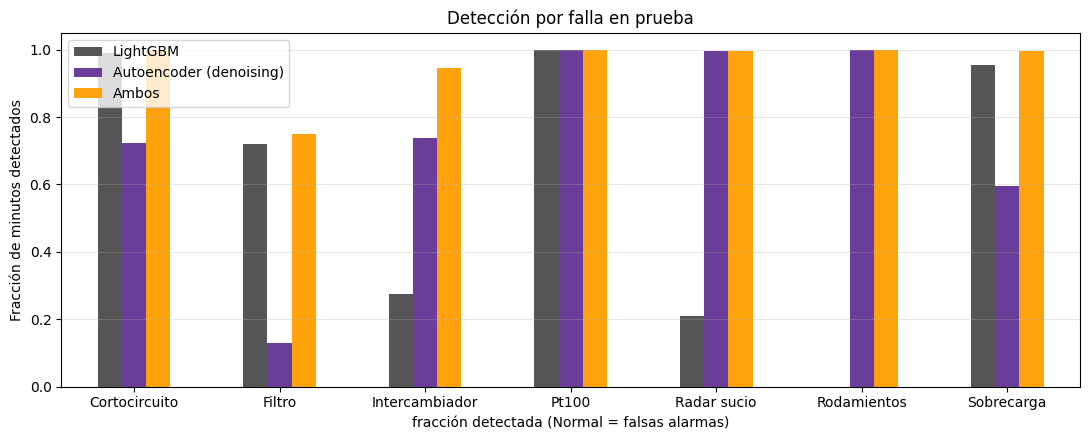

In [17]:
fig, ax = plt.subplots(figsize=(11, 4.5))
complemento.drop(index="Normal").plot(kind="bar", ax=ax, color=["#555", "#6A3D9A", "#FEA30B"])
ax.set_ylabel("Fracción de minutos detectados"); ax.set_ylim(0, 1.05); ax.tick_params(axis="x", rotation=0)
ax.set_title("Detección por falla en prueba"); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

# 6. Interpretación de las alarmas

## 6.1 ¿Qué sensores explican la anomalía?

El error por sensor indica dónde está el problema, sin haber entrenado con etiquetas de falla.

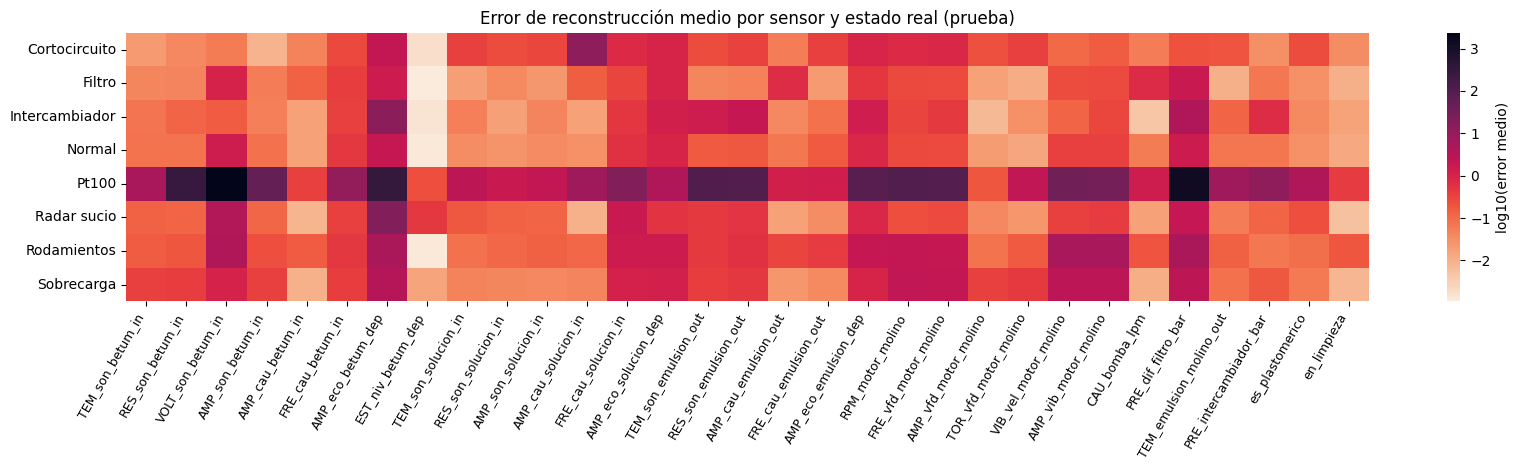

Tres sensores con mayor error en cada falla:
  Cortocircuito   -> AMP_cau_solucion_in, AMP_eco_betum_dep, AMP_eco_solucion_dep
  Filtro          -> PRE_dif_filtro_bar, AMP_eco_betum_dep, VOLT_son_betum_in
  Intercambiador  -> AMP_eco_betum_dep, PRE_dif_filtro_bar, RES_son_emulsion_out
  Pt100           -> VOLT_son_betum_in, PRE_dif_filtro_bar, AMP_eco_betum_dep
  Radar sucio     -> AMP_eco_betum_dep, VOLT_son_betum_in, PRE_dif_filtro_bar
  Rodamientos     -> VIB_vel_motor_molino, AMP_vib_motor_molino, AMP_eco_betum_dep
  Sobrecarga      -> AMP_eco_betum_dep, AMP_vib_motor_molino, VIB_vel_motor_molino


In [18]:
err_sensor = pd.DataFrame((X_test - mejor_ae.predict(X_test, verbose=0, batch_size=4096)) ** 2, columns=FEATURES)
contrib = err_sensor.groupby(etq_c).mean()
plt.figure(figsize=(17, 4.8))
sns.heatmap(np.log10(contrib + 1e-3), cmap="rocket_r", cbar_kws={"label": "log10(error medio)"})
plt.title("Error de reconstrucción medio por sensor y estado real (prueba)")
plt.xticks(rotation=60, ha="right", fontsize=9); plt.tight_layout(); plt.show()

print("Tres sensores con mayor error en cada falla:")
for estado, fila in contrib.drop(index="Normal").iterrows():
    print(f"  {estado:<15} -> {', '.join(fila.sort_values(ascending=False).index[:3])}")

## 6.2 El error sube antes de la falla

Se agrupa el error de los minutos **normales** de prueba según cuánto falta para la próxima falla. Si el autoencoder capta la degradación, el error debería crecer al acercarse la falla.

In [19]:
normal_te = y_test == 0
tramos, nombres = [0, 24, 72, 168, 360, np.inf], ["< 1 día", "1-3 días", "3-7 días", "7-15 días", "> 15 días"]
grupo = pd.cut(df.loc[te, "horas_a_falla"].values[normal_te], tramos, labels=nombres)
tabla_prev = pd.DataFrame({"error_medio": pd.Series(err_test[normal_te]).groupby(grupo).mean(),
                           "% sobre el umbral": pd.Series(err_test[normal_te] > UMBRAL).groupby(grupo).mean() * 100,
                           "minutos": pd.Series(grupo).value_counts()}).reindex(nombres[::-1])
tabla_prev.index.name = "tiempo hasta la próxima falla (minutos normales)"
tabla_prev.round(3)

,error_medio,% sobre el umbral,minutos
tiempo hasta la próxima falla (minutos normales),,,
> 15 días,0.290,13.798,2051
7-15 días,0.195,2.161,3795
3-7 días,0.336,16.516,2761
1-3 días,0.433,32.633,2142
< 1 día,0.538,45.807,1908


## 6.3 Índice de salud del molino

El error medio diario del autoencoder resume en un solo número qué tan lejos está el molino de su comportamiento sano. En el dashboard se muestra en la pestaña "Salud del equipo".

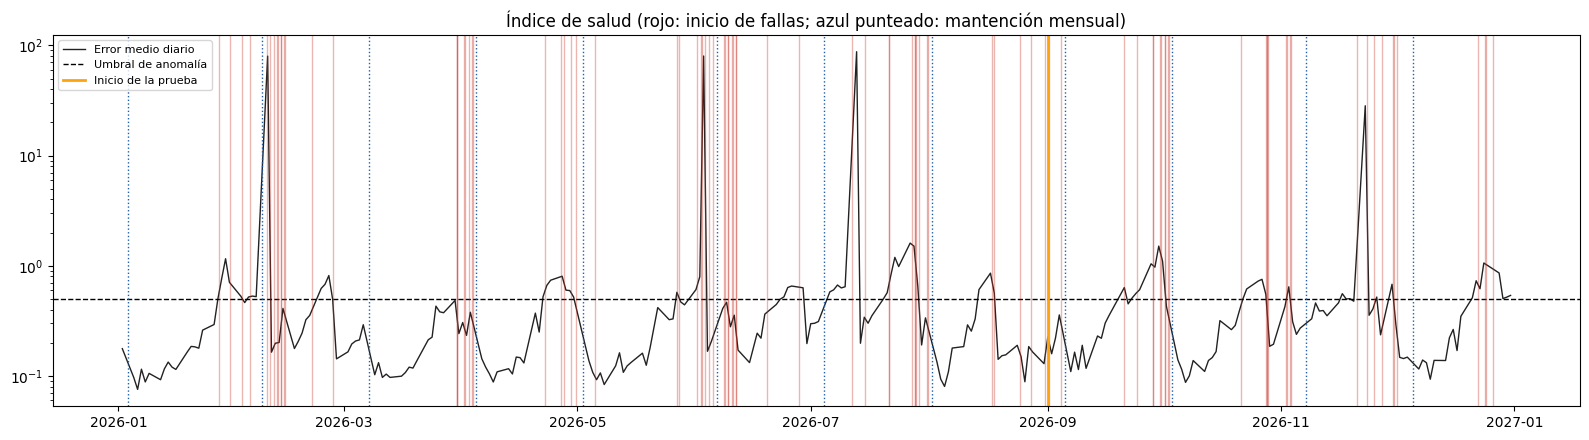

In [20]:
err_todo = error_rec(mejor_ae, X)
salud = pd.Series(err_todo, index=df["timestamp"]).resample("D").mean().dropna()
fig, ax = plt.subplots(figsize=(16, 4.5))
ax.plot(salud.index, salud.values, color="#222", lw=1, label="Error medio diario")
ax.axhline(UMBRAL, color="black", ls="--", lw=1, label="Umbral de anomalía")
for s in inicio_fallas:
    ax.axvline(s, color="#C62D1F", alpha=0.35, lw=1)
for m in bit.loc[bit["tipo"] != "Correctiva", "timestamp"]:
    ax.axvline(m, color="#1F5FA8", ls=":", lw=1)
ax.axvline(FIN_VA, color="#FEA30B", lw=2, label="Inicio de la prueba")
ax.set_yscale("log"); ax.set_title("Índice de salud (rojo: inicio de fallas; azul punteado: mantención mensual)")
ax.legend(loc="upper left", fontsize=8); plt.tight_layout(); plt.show()

## 6.4 Sensibilidad del umbral

In [21]:
e_vs = error_rec(mejor_ae, X_val_sano)
filas = []
for p in [95, 97.5, 99, 99.5, 99.9]:
    u = np.percentile(e_vs, p)
    m = metricas(err_test, y_test, u)
    filas.append({"percentil": p, "umbral": u, "recall": m["recall"], "precision": m["precision"], "FAR": m["FAR"]})
pd.DataFrame(filas).set_index("percentil").round(4)

,umbral,recall,precision,FAR
percentil,,,,
95.0,0.3822,0.7613,0.2236,0.3378
97.5,0.4277,0.7069,0.2497,0.2714
99.0,0.5022,0.6376,0.3010,0.1891
99.5,0.5751,0.5714,0.3555,0.1323
99.9,4.3384,0.0173,0.7000,0.0009


## 6.5 Alarma con persistencia

Una alarma por minuto aislado es demasiado sensible para operación. En la práctica se exige que la anomalía **persista**: se alarma solo si al menos 30 de los últimos 60 minutos en marcha superan el umbral. Así se filtran desviaciones breves y quedan las sostenidas.

In [22]:
def persistente(alarma, ventana=60, minimo=30):
    return pd.Series(alarma.astype(float)).rolling(ventana, min_periods=1).sum().values >= minimo

alarma_ae_p = persistente(err_test > UMBRAL)
alarma_ambos_p = alarma_lgbm | alarma_ae_p
persistencia = pd.DataFrame({
    "Autoencoder por minuto": pd.Series(err_test > UMBRAL).groupby(etq_c).mean(),
    "Autoencoder con persistencia": pd.Series(alarma_ae_p).groupby(etq_c).mean(),
    "LightGBM + autoencoder con persistencia": pd.Series(alarma_ambos_p).groupby(etq_c).mean(),
}).round(3)
persistencia.index.name = "fracción detectada (Normal = falsas alarmas)"
persistencia

,Autoencoder por minuto,Autoencoder con persistencia,LightGBM + autoencoder con persistencia
fracción detectada (Normal = falsas alarmas),,,
Cortocircuito,0.724,0.770,1.000
Filtro,0.129,0.098,0.720
Intercambiador,0.737,0.711,0.947
Normal,0.189,0.155,0.157
Pt100,1.000,0.500,1.000
Radar sucio,0.995,0.867,0.886
Rodamientos,1.000,1.000,1.000
Sobrecarga,0.596,0.503,0.995


# 7. Conclusiones

*(Valores de la ejecución de referencia; pueden variar levemente entre corridas.)*

## 7.1 Mejor variante: denoising

| Variante | PR-AUC validación | PR-AUC prueba | Recall | Falsas alarmas (FAR) |
|---|---|---|---|---|
| **Denoising** | **0,46** | **0,48** | 64 % | 18,9 % |
| Combinado | 0,44 | 0,45 | 61 % | 18,7 % |
| L2 | 0,41 | 0,41 | 64 % | 32,1 % |
| Dropout | 0,39 | 0,40 | 55 % | 15,4 % |
| Base | 0,38 | 0,37 | 57 % | 22,8 % |
| Sparse | 0,38 | 0,35 | 53 % | 21,8 % |

* **Denoising** (ruido gaussiano en la entrada) fue la mejor: al aprender a reconstruir la lectura limpia desde una ruidosa, aprende relaciones más robustas entre sensores y separa mejor la falla de la operación normal.
* **L2** reconstruye mejor la operación sana (menor error), pero también reconstruye mejor las anomalías y casi duplica las falsas alarmas. Es el caso clásico de un autoencoder demasiado flexible.
* El autoencoder supera claramente a **PCA** (PR-AUC 0,25) y a **Isolation Forest** (0,24). A diferencia del dataset anterior, aquí las relaciones entre sensores no son lineales (dependen del tipo de asfalto, del estado de operación y de la carga del motor), y la red neuronal sí aprovecha esa ventaja.

## 7.2 El autoencoder cubre justo lo que LightGBM no detecta

| Falla | LightGBM | Autoencoder | Ambos |
|---|---|---|---|
| Radar sucio | 21 % | 99 % | 99 % |
| Intercambiador | 28 % | 74 % | 95 % |
| Rodamientos | 0 % | 100 % | 100 % |
| Sobrecarga | 95 % | 60 % | 99 % |
| Filtro | 72 % | 13 % | 75 % |
| Cortocircuito y Pt100 | 99–100 % | 72–100 % | 100 % |

Las tres fallas raras que el modelo supervisado no lograba aprender (radar, intercambiador y rodamientos) pasan de una detección baja o nula a **95–100 %** al combinar ambos modelos. El autoencoder lo logra sin haber visto ni un minuto de esas fallas.

Además, **apunta a los sensores correctos**: en rodamientos señala la vibración, en radar el eco, en cortocircuito el lazo de caudal, en filtro la presión diferencial y en Pt100 el voltaje de alimentación.

## 7.3 La limitación: muchas alarmas en operación "normal"

El autoencoder marca como anómalo cerca del **19 % de los minutos normales** de prueba, y exigir persistencia (30 de 60 minutos) solo lo reduce a 15,5 %. Esas alarmas no son ruido aislado: son **estados sostenidos de degradación**. La sección 6.2 lo muestra:

* A 7–15 días de una falla, solo el 2 % de los minutos supera el umbral.
* A 1–3 días, el 33 %.
* A menos de un día, el 46 %.

Es decir, el autoencoder detecta que el equipo **se está degradando**, aunque la etiqueta todavía diga "Normal". Esa sensibilidad es lo que lo hace útil para fallas raras, pero lo hace inadecuado como alarma inmediata por sí solo.

## 7.4 Recomendación de uso en el dashboard

1. **No usarlo como alarma principal.** Las alarmas de acción inmediata deben venir de LightGBM (falsas alarmas 1,4 %) y de las reglas fijas.
2. **Usarlo como "aviso de degradación"**, de prioridad baja: "el molino se aleja de su comportamiento sano, revisar estos sensores".
3. **Usarlo como alarma solo cuando LightGBM dice "Normal" y el autoencoder señala sensores de las fallas raras** (vibración, eco del radar, presión del intercambiador).
4. **Usar su error diario como índice de salud** en la pestaña "Salud del equipo": sube de forma clara al acercarse las fallas y baja después de cada mantención.

## 7.5 Próximos pasos

* Definir "operación sana" con la bitácora, por equipo: por ejemplo, los primeros días después de cada limpieza de radar o cambio de rodamientos. Eso debería reducir las falsas alarmas.
* Entrenar autoencoders separados por tipo de asfalto si con datos reales la diferencia entre convencional y plastomérico resulta mayor.
* Validar con datos reales de la planta y ajustar el percentil del umbral según la cantidad de avisos que el equipo de mantención pueda atender.


# 8. Exportación del modelo

Se empaquetan en un `.zip`:

* `autoencoder_molino_QLA.keras`: la red entrenada.
* `autoencoder_molino_config.joblib`: escalador, variables en orden, umbral, alcance y variables de contexto.

In [23]:
mejor_ae.save("autoencoder_molino_QLA.keras")
joblib.dump({"scaler": scaler, "features": FEATURES, "umbral": UMBRAL, "percentil_umbral": PERCENTIL, "variante": MEJOR,
             "alcance": "Solo minutos con el molino en marcha: ESTADO_operacion en {Produccion, Limpieza}",
             "contexto": {"es_plastomerico": "1 si TIPO_asfalto == 'Plastomerico'", "en_limpieza": "1 si ESTADO_operacion == 'Limpieza'"},
             "versiones": {"tensorflow": tf.__version__, "sklearn": sklearn.__version__}},
            "autoencoder_molino_config.joblib")
ZIP = "autoencoder_molino_QLA.zip"
with zipfile.ZipFile(ZIP, "w") as z:
    z.write("autoencoder_molino_QLA.keras"); z.write("autoencoder_molino_config.joblib")
print("Archivo creado:", ZIP)
try:
    from google.colab import files
    files.download(ZIP)
except ImportError:
    print("No se está ejecutando en Colab: el .zip quedó en la carpeta actual.")

Archivo creado: autoencoder_molino_QLA.zip
No se está ejecutando en Colab: el .zip quedó en la carpeta actual.


## 8.1 Cómo usar el modelo descargado

In [24]:
from tensorflow.keras.models import load_model
ae_cargado = load_model("autoencoder_molino_QLA.keras")
cfg = joblib.load("autoencoder_molino_config.joblib")

def detectar_anomalias(df_lecturas, top=3):
    d = df_lecturas.copy()
    d["es_plastomerico"] = (d["TIPO_asfalto"] == "Plastomerico").astype(int)
    d["en_limpieza"] = (d["ESTADO_operacion"] == "Limpieza").astype(int)
    salida = []
    for _, fila in d.iterrows():
        if fila["ESTADO_operacion"] not in ("Produccion", "Limpieza"):
            salida.append({"error": None, "mensaje": "[Molino detenido: fuera del alcance del modelo]"}); continue
        Z = cfg["scaler"].transform(fila[cfg["features"]].to_frame().T.astype(float)).astype("float32")
        e_s = ((Z - ae_cargado.predict(Z, verbose=0)) ** 2)[0]
        e = float(e_s.mean())
        if e <= cfg["umbral"]:
            salida.append({"error": round(e, 4), "mensaje": "[OK: Continuar Monitoreo]"})
        else:
            peores = [cfg["features"][i] for i in np.argsort(e_s)[::-1][:top]]
            salida.append({"error": round(e, 4), "mensaje": f"[ALERTA] Anomalía. Revisar: {', '.join(peores)}"})
    return pd.DataFrame(salida)

ejemplo = df_completo[df_completo["ESTADO_operacion"].isin(["Produccion", "Limpieza"])].groupby(TARGET).sample(1, random_state=5)
pd.concat([ejemplo[["timestamp", TARGET]].reset_index(drop=True), detectar_anomalias(ejemplo)], axis=1)

,timestamp,LABEL_Estado_Planta,error,mensaje
0,2026-01-30 09:19:00,Advertencia_Radar_Sucio_Betun,0.8431,"[ALERTA] Anomalía. Revisar: AMP_eco_betum_dep,..."
1,2026-07-15 10:24:00,Cortocircuito_Transmisor_Caudal_Sol,0.5699,[ALERTA] Anomalía. Revisar: AMP_cau_solucion_i...
2,2026-07-29 10:00:00,Desgaste_Rodamientos_Molino,0.9141,[ALERTA] Anomalía. Revisar: FRE_vfd_motor_moli...
3,2026-06-02 14:53:00,Ensuciamiento_Intercambiador,0.7356,"[ALERTA] Anomalía. Revisar: VOLT_son_betum_in,..."
4,2026-02-09 09:52:00,Falla_Electrica_PT100_Betun,178.8604,"[ALERTA] Anomalía. Revisar: VOLT_son_betum_in,..."
5,2026-08-17 10:04:00,Filtro_Obstruido,0.6715,"[ALERTA] Anomalía. Revisar: AMP_eco_betum_dep,..."
6,2026-10-22 09:03:00,Normal,0.6725,"[ALERTA] Anomalía. Revisar: AMP_eco_betum_dep,..."
7,2026-03-30 09:36:00,Sobrecarga_Motor_Por_Asfalto_Frio,0.5648,"[ALERTA] Anomalía. Revisar: AMP_eco_betum_dep,..."
